# 같은구 이동 포함 전체 5km 커버리지 분석 (04_1 후속)

## 배경 및 목적

`04_1_inter_gu_movement_distance_analysis.ipynb`에서 **가설 1(데이터 가설)은 채택**됐지만, **가설 2(서비스 설계 가설)는 제한적으로만 지지**됐다 — Top 30(다른구 이동)조차 5km 초과 비율이 55.7%로 과반이었기 때문이다.

04_1은 **"다른 구 간 이동"만**(전체 탑승내역의 61.4%) 대상으로 했는데, 가설 2가 묻는 건 "**주요 수요**를 5km 안내로 얼마나 포괄하는가"이다. 나머지 38.6%를 차지하는 **"같은 구 내 이동"**은 구 경계를 넘지 않으므로 대체로 짧을 가능성이 높고, 이를 빼놓은 채로는 가설 2에 제대로 답할 수 없다.

> **가설 2-A (전체 수요 커버리지 가설)**: 같은구 이동을 포함한 전체 이동(같은구+다른구) 기준으로 볼 때, 5km 이내 이동 비중이 절반 내외를 차지하여 "5km 이내 경로 안내"가 전체 수요의 상당 부분을 커버할 수 있다.
>
> **가설 2-B (같은구 내부 편차 가설)**: 같은구 이동이라도 자치구에 따라 5km 이내 비율에 뚜렷한 차이가 있을 것이다.

이번 분석은 04_1과 짝을 이뤄 **"04_1(다른구, Top30 중심) + 04_2(같은구 포함 전체 커버리지)"**로 가설 2에 대한 완전한 답을 제공하는 것을 목표로 한다.

**서비스 설계와의 연결**: 04_1에서는 "다른구 이동만 보면 5km 안내가 절반 이상을 놓친다"는 다소 비관적인 결론이었지만, 같은구 이동까지 포함하면 전체 수요 중 상당 부분은 이미 5km 이내라는 그림이 나올 수 있다. 서비스가 "5km 이내 우선 안내" 설계를 검토할 때, 이 두 결과를 함께 봐야 정확한 기대치를 세울 수 있다.

계획 문서: `notebooks_docs_lye/260910_같은구_다른구_전체_5km_커버리지_분석_계획.md` (사용자 승인 완료 2026-09-11)


In [1]:
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

boarding_path = DATA_DIR / "서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv"
print(boarding_path)

df = pd.read_csv(boarding_path)
print(f"전체 행 수: {len(df):,}")
df.head()


c:\Users\young\my_project\260901_call_taxi_DA\data\processed\서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv
전체 행 수: 1,722,490


,접수일시,예정일시,배차일시,승차일시,하차일시,취소일시,출발구,출발동,목적구,목적동,이용목적,요금,승차거리,차량구분,장애유형
0,2025-01-01 00:01:26.127,2025-01-01 00:01:26.127,2025-01-01 00:27:31.307,2025-01-01 00:49:52.967,2025-01-01 01:35:06.747,NaN,용산구,남영동,강북구,수유제2동,기타,3400.0,17667,특장차,지체
1,2025-01-01 00:03:10.557,2025-01-01 00:03:10.557,2025-01-01 00:14:39.800,NaN,NaN,2025-01-01 00:21:15.000,영등포구,여의동,강서구,화곡제6동,기타,NaN,0,특장차,뇌병
2,2025-01-01 00:03:31.230,2025-01-01 00:04:00.000,2025-01-01 00:19:41.900,2025-01-01 00:36:18.433,2025-01-01 00:49:45.857,NaN,노원구,상계5동,노원구,하계1동,기타,1500.0,2910,특장차,뇌병
3,2025-01-01 00:03:40.573,2025-01-01 00:04:00.000,2025-01-01 00:33:41.650,2025-01-01 00:53:48.440,2025-01-01 01:33:38.120,NaN,영등포구,당산제1동,중구,명동,기타,2900.0,10421,특장차,지체
4,2025-01-01 00:04:15.077,2025-01-01 00:04:15.077,2025-01-01 00:06:33.790,2025-01-01 00:40:07.840,2025-01-01 01:10:15.110,NaN,송파구,오금동,서초구,내곡동,기타,3000.0,11943,특장차,지체


In [2]:
use_cols = ["출발구", "목적구", "승차거리", "승차일시", "하차일시", "취소일시"]

missing_counts = df[use_cols].isna().sum()
print("사용 컬럼 결측치 개수")
display(missing_counts.to_frame("결측치_건수"))

print(f"\n승차거리 = 0 건수: {(df['승차거리'] == 0).sum():,}")
print(f"승차거리 < 0 건수: {(df['승차거리'] < 0).sum():,}")
print(f"승차거리 기술통계:\n{df['승차거리'].describe()}")


사용 컬럼 결측치 개수


,결측치_건수
출발구,1
목적구,1
승차거리,0
승차일시,245361
하차일시,245423
취소일시,1477193



승차거리 = 0 건수: 245,423
승차거리 < 0 건수: 0
승차거리 기술통계:
count    1.722490e+06
mean     7.332305e+03
std      9.291749e+03
min      0.000000e+00
25%      2.111000e+03
50%      4.541000e+03
75%      9.508000e+03
max      8.094630e+05
Name: 승차거리, dtype: float64


## 데이터 출처 및 단위

**메인 데이터**: `data/processed/서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv` — 서울시설공단 원본을 팀이 전처리한 정제본 (`02_od_flow_same_vs_diff_gu.ipynb`, `03_same_gu_movement_analysis.ipynb`, `04_1_inter_gu_movement_distance_analysis.ipynb`와 동일 소스). 이 중 `출발구`, `목적구`, `승차거리`, `승차일시`, `하차일시`, `취소일시` 컬럼을 사용한다.

**`승차거리` 단위**: m(미터)로 추정(04_1과 동일 근거). 계산은 m 단위(5km 기준 = 5,000m)로 하되, 그래프에 보이는 축·라벨은 km로 통일한다.

**`승차거리 = 0`의 의미**: 결측치는 아니지만, 탑승완료(승차·하차 기록 존재)되지 않은 건(취소 등)에서만 나타난다(04_1에서 확인됨) — 결측치와 동일하게 취급해 분석 전 반드시 제외한다.

**이번 분석의 신규 기여분**: `03_same_gu_movement_analysis.ipynb`은 같은구 이동의 승차거리 평균·중앙값은 이미 다뤘지만 **"5km 이내 비율"** 지표는 없었다. 이번 분석은 04_1의 다른구 이동 결과와 짝을 맞춰, 같은구 이동에 5km 이내 비율을 새로 계산하고 같은구/다른구/전체를 하나의 커버리지 그림으로 통합한다.


In [3]:
completed = df[
    df["승차일시"].notna()
    & df["하차일시"].notna()
    & df["취소일시"].isna()
].copy()

print(f"탑승완료 건수: {len(completed):,} / 전체 {len(df):,} ({len(completed) / len(df) * 100:.1f}%)")


탑승완료 건수: 1,477,067 / 전체 1,722,490 (85.8%)


In [4]:
OUTLIER_THRESHOLD_M = 100_000  # 100km

# 같은구 이동에는 100km 초과 이상치가 존재하지 않는다는 계획 문서(§3-1)의 사전 확인을 재검증
same_gu_precheck = completed[completed["출발구"] == completed["목적구"]]
same_gu_outliers_precheck = same_gu_precheck[same_gu_precheck["승차거리"] > OUTLIER_THRESHOLD_M]
print(f"[사전 검증] 같은구 이동 중 100km 초과 건수: {len(same_gu_outliers_precheck):,} / {len(same_gu_precheck):,}건")
print(f"[사전 검증] 같은구 이동 승차거리 최댓값: {same_gu_precheck['승차거리'].max():,.0f}m")

before_rows = len(completed)
outliers = completed[completed["승차거리"] > OUTLIER_THRESHOLD_M]

print(f"\n탑승완료 기준 100km 초과 이상치(전체): {len(outliers):,}건 ({len(outliers) / before_rows * 100:.3f}%)")

completed = completed[completed["승차거리"] <= OUTLIER_THRESHOLD_M].copy()

after_rows = len(completed)
print(f"\n제거 전 행 수: {before_rows:,}")
print(f"제거 후 행 수: {after_rows:,}")
print(f"제거된 행 수: {before_rows - after_rows:,}")

n_same_gu_outliers = len(same_gu_outliers_precheck)
n_diff_gu_outliers = len(outliers) - n_same_gu_outliers
print(
    f"\n※ 계획 문서(§3-1)의 사전 확인(같은구 최댓값 89,572m 기준 '이상치 없음')과 달리, "
    f"실제로는 같은구 이동 중 {n_same_gu_outliers}건이 100km를 초과함(최댓값 {same_gu_precheck['승차거리'].max():,.0f}m,"
    f" 출발구=목적구인데 800km대 승차거리가 기록된 명백한 GPS/기록 오류로 추정). "
    f"즉 이번 제거는 같은구 {n_same_gu_outliers}건 + 다른구 {n_diff_gu_outliers}건에 영향을 준다 — "
    f"'같은구에는 영향 없음'이라는 계획 문서의 가정은 이번 실행으로 정정한다."
)


[사전 검증] 같은구 이동 중 100km 초과 건수: 19 / 526,119건
[사전 검증] 같은구 이동 승차거리 최댓값: 806,728m

탑승완료 기준 100km 초과 이상치(전체): 92건 (0.006%)

제거 전 행 수: 1,477,067
제거 후 행 수: 1,476,975
제거된 행 수: 92

※ 계획 문서(§3-1)의 사전 확인(같은구 최댓값 89,572m 기준 '이상치 없음')과 달리, 실제로는 같은구 이동 중 19건이 100km를 초과함(최댓값 806,728m, 출발구=목적구인데 800km대 승차거리가 기록된 명백한 GPS/기록 오류로 추정). 즉 이번 제거는 같은구 19건 + 다른구 73건에 영향을 준다 — '같은구에는 영향 없음'이라는 계획 문서의 가정은 이번 실행으로 정정한다.


In [5]:
SEOUL_25 = [
    "종로구", "중구", "용산구", "성동구", "광진구",
    "동대문구", "중랑구", "성북구", "강북구", "도봉구",
    "노원구", "은평구", "서대문구", "마포구", "양천구",
    "강서구", "구로구", "금천구", "영등포구", "동작구",
    "관악구", "서초구", "강남구", "송파구", "강동구",
]

seoul_completed = completed[
    completed["출발구"].isin(SEOUL_25) & completed["목적구"].isin(SEOUL_25)
].copy()

print(f"탑승완료(이상치 제거) 중 서울 25구 내부 이동: {len(seoul_completed):,} / {len(completed):,} ({len(seoul_completed) / len(completed) * 100:.1f}%)")


탑승완료(이상치 제거) 중 서울 25구 내부 이동: 1,362,621 / 1,476,975 (92.3%)


In [6]:
same_gu = seoul_completed[seoul_completed["출발구"] == seoul_completed["목적구"]].copy()
diff_gu = seoul_completed[seoul_completed["출발구"] != seoul_completed["목적구"]].copy()

print(f"같은구 이동: {len(same_gu):,}건 ({len(same_gu) / len(seoul_completed) * 100:.1f}%)")
print(f"다른구 이동: {len(diff_gu):,}건 ({len(diff_gu) / len(seoul_completed) * 100:.1f}%)")
print(f"전체(같은구+다른구): {len(seoul_completed):,}건")

print("\n※ 기존 노트북과의 대조 (참고용, 필터 순서·시점 차이로 소수점 단위 오차가 있을 수 있음)")
print(f"  - 04_1의 다른구 이동(동일 파이프라인): 836,535건 → 이번 계산: {len(diff_gu):,}건 (차이 {len(diff_gu) - 836535:+,}건)")
print(f"  - 계획 문서(260910 §3-1) 예비 확인치: 같은구 526,086건(38.6%) → 이번 계산: {len(same_gu):,}건 ({len(same_gu) / len(seoul_completed) * 100:.1f}%) (차이 {len(same_gu) - 526086:+,}건)")


같은구 이동: 526,086건 (38.6%)
다른구 이동: 836,535건 (61.4%)
전체(같은구+다른구): 1,362,621건

※ 기존 노트북과의 대조 (참고용, 필터 순서·시점 차이로 소수점 단위 오차가 있을 수 있음)
  - 04_1의 다른구 이동(동일 파이프라인): 836,535건 → 이번 계산: 836,535건 (차이 +0건)
  - 계획 문서(260910 §3-1) 예비 확인치: 같은구 526,086건(38.6%) → 이번 계산: 526,086건 (38.6%) (차이 +0건)


In [7]:
same_gu["5km이내"] = same_gu["승차거리"] <= 5000
diff_gu["5km이내"] = diff_gu["승차거리"] <= 5000

same_gu["구분"] = "같은구"
diff_gu["구분"] = "다른구"

all_moves = pd.concat([same_gu, diff_gu], ignore_index=True)
print(f"전체(같은구+다른구) 이동: {len(all_moves):,}건")
print(f"같은구 5km이내비율(예비): {same_gu['5km이내'].mean() * 100:.1f}%")
print(f"다른구 5km이내비율(예비, 04_1 baseline과 대조): {diff_gu['5km이내'].mean() * 100:.1f}%")


전체(같은구+다른구) 이동: 1,362,621건
같은구 5km이내비율(예비): 88.7%
다른구 5km이내비율(예비, 04_1 baseline과 대조): 25.2%


In [8]:
def coverage_stats(g):
    n = len(g)
    within = g["5km이내"].mean()
    return pd.Series({
        "건수": n,
        "5km이내비율(%)": within * 100,
        "5km초과비율(%)": (1 - within) * 100,
    })

coverage_summary = pd.DataFrame({
    "같은구": coverage_stats(same_gu),
    "다른구": coverage_stats(diff_gu),
    "전체": coverage_stats(all_moves),
}).T
coverage_summary.index.name = "구분"
display(coverage_summary)


,건수,5km이내비율(%),5km초과비율(%)
구분,,,
같은구,526086.0,88.748988,11.251012
다른구,836535.0,25.228831,74.771169
전체,1362621.0,49.752939,50.247061


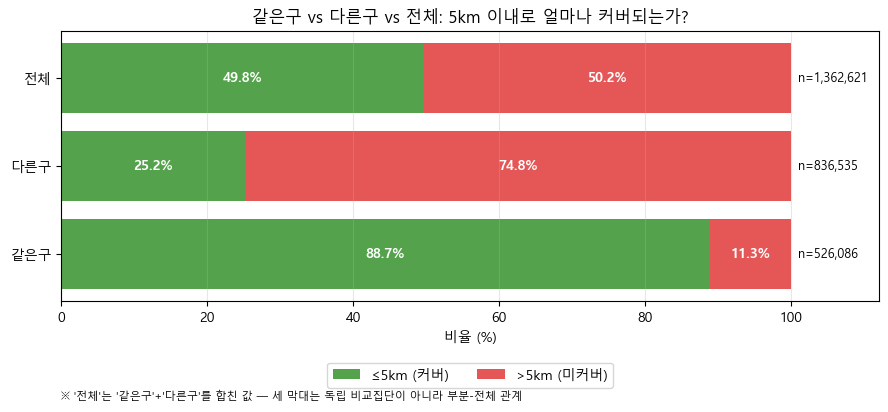

In [9]:
categories = ["같은구", "다른구", "전체"]
within_pct = coverage_summary.loc[categories, "5km이내비율(%)"].tolist()
over_pct = coverage_summary.loc[categories, "5km초과비율(%)"].tolist()
counts = coverage_summary.loc[categories, "건수"].tolist()

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.barh(categories, within_pct, color="#54a24b", label="≤5km (커버)")
ax.barh(categories, over_pct, left=within_pct, color="#e45756", label=">5km (미커버)")

for i, (w, o, n) in enumerate(zip(within_pct, over_pct, counts)):
    ax.text(w / 2, i, f"{w:.1f}%", ha="center", va="center", color="white", fontweight="bold")
    ax.text(w + o / 2, i, f"{o:.1f}%", ha="center", va="center", color="white", fontweight="bold")
    ax.text(101, i, f"n={n:,.0f}", va="center", fontsize=9)

ax.set_xlim(0, 112)
ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.set_xlabel("비율 (%)")
ax.set_title("같은구 vs 다른구 vs 전체: 5km 이내로 얼마나 커버되는가?")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2)
ax.grid(axis="x", alpha=0.3)
ax.annotate(
    "※ '전체'는 '같은구'+'다른구'를 합친 값 — 세 막대는 독립 비교집단이 아니라 부분-전체 관계",
    xy=(0, -0.36), xycoords="axes fraction", fontsize=8, ha="left",
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig1_04_2_coverage_same_vs_diff_vs_all.png", dpi=120, bbox_inches="tight")
plt.show()


## 가설 2-A 해석 (§2 실행 결과로 확정)

- 같은구 이동의 5km 이내 비율은 **88.7%**(정확히 88.75%, n=526,086), 다른구 이동은 **25.2%**(정확히 25.23%, n=836,535, 04_1 baseline과 완전히 일치)로, 같은구가 다른구보다 압도적으로 높다.
- 같은구+다른구를 합친 **전체 5km 이내 비율은 49.8%**(정확히 49.75%, n=1,362,621)다 — 같은구 비중(38.6%)과 다른구 비중(61.4%)으로 가중 평균된 값이며, 다른구 단독 baseline(25.2%)보다는 높고 같은구 단독(88.7%)보다는 훨씬 낮다.
- 04_1의 결론("다른구만 보면 5km 안내가 수요의 절반 이상을 놓친다")과 비교하면, 같은구 이동까지 포함한 전체 그림(49.8% 커버)은 그보다 뚜렷하게 낙관적이다 — 서비스가 "5km 이내 우선 안내"를 설계할 때는 다른구 이동만이 아니라 전체 이동 중 같은구 비중(38.6%)이 대부분(88.7%) 커버된다는 점을 함께 고려해야 한다.
- **가설 2-A는 채택**: 전체 기준 5km 이내 비중(49.8%)이 절반 내외를 차지한다는 가설과 부합한다.


In [10]:
by_district = (
    same_gu.groupby("출발구")
    .agg(
        이동건수=("5km이내", "size"),
        **{"5km이내건수": ("5km이내", "sum")},
    )
    .reset_index()
    .rename(columns={"출발구": "자치구"})
)
by_district["5km이내비율"] = by_district["5km이내건수"] / by_district["이동건수"]
by_district["5km초과비율"] = 1 - by_district["5km이내비율"]
by_district = by_district.sort_values("5km이내비율", ascending=False).reset_index(drop=True)

overall_same_gu_ratio = same_gu["5km이내"].mean()
print(f"같은구 이동 전체 5km 이내 비율(평균): {overall_same_gu_ratio * 100:.1f}%")
print(f"자치구별 범위: {by_district['5km이내비율'].min() * 100:.1f}% ~ {by_district['5km이내비율'].max() * 100:.1f}% (n={len(by_district)}개구)")
display(by_district)


같은구 이동 전체 5km 이내 비율(평균): 88.7%
자치구별 범위: 67.6% ~ 98.6% (n=25개구)


,자치구,이동건수,5km이내건수,5km이내비율,5km초과비율
0,강북구,12894,12709,0.985652,0.014348
1,금천구,7486,7369,0.984371,0.015629
2,성동구,7487,7303,0.975424,0.024576
3,도봉구,15201,14816,0.974673,0.025327
4,중랑구,23548,22824,0.969254,0.030746
5,영등포구,14254,13756,0.965062,0.034938
6,광진구,14957,14159,0.946647,0.053353
7,동대문구,19010,17946,0.944029,0.055971
8,노원구,83556,78641,0.941177,0.058823
9,성북구,14299,13294,0.929715,0.070285


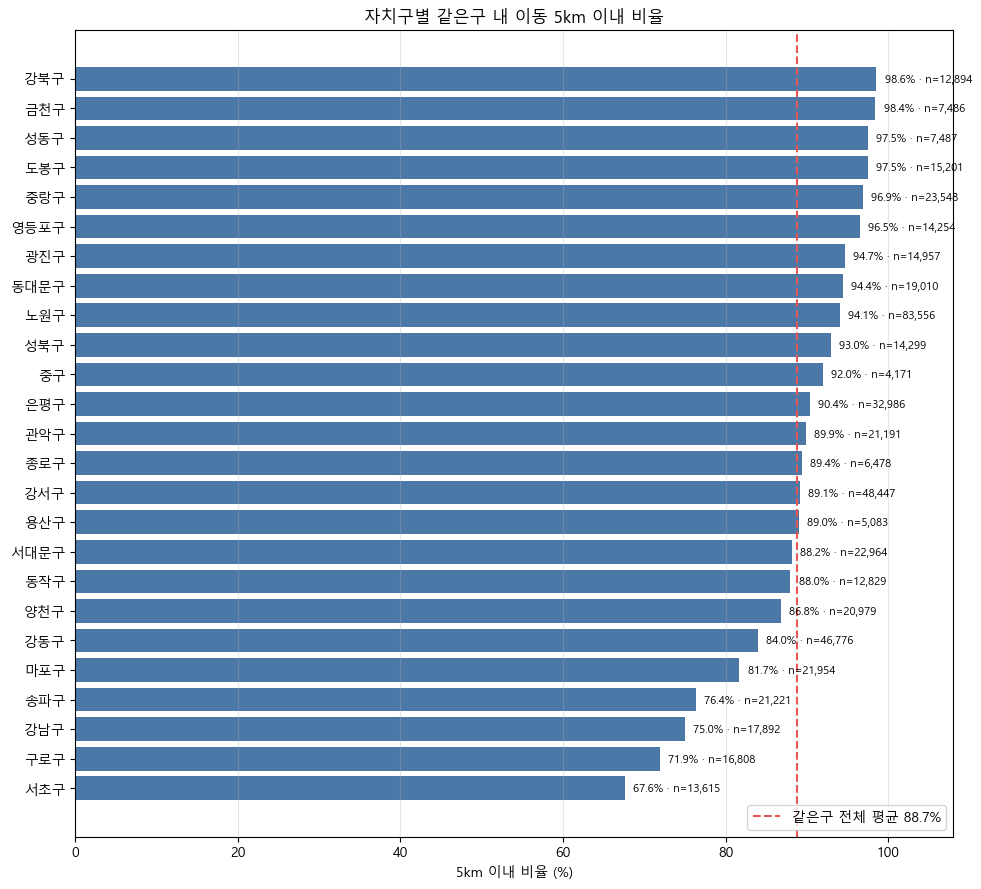

In [11]:
plot_data = by_district.sort_values("5km이내비율", ascending=True).copy()

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(plot_data["자치구"], plot_data["5km이내비율"] * 100, color="#4c78a8")

ax.axvline(
    overall_same_gu_ratio * 100, color="#e45756", linestyle="--", linewidth=1.5,
    label=f"같은구 전체 평균 {overall_same_gu_ratio * 100:.1f}%",
)

for i, (ratio, n) in enumerate(zip(plot_data["5km이내비율"], plot_data["이동건수"])):
    ax.text(ratio * 100 + 1, i, f"{ratio * 100:.1f}% · n={n:,}", va="center", fontsize=8)

ax.set_xlim(0, 108)
ax.set_xlabel("5km 이내 비율 (%)")
ax.set_title("자치구별 같은구 내 이동 5km 이내 비율")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig2_04_2_same_gu_ratio_by_district.png", dpi=120, bbox_inches="tight")
plt.show()


## 가설 2-B 관찰 기록 (§3 실행 결과로 확정)

자치구별 같은구 이동 5km 이내 비율은 **67.6%(서초구) ~ 98.6%(강북구)**로 약 **31.0%p** 차이를 보인다(위 셀 13·14 실행 결과).

- 최고: 강북구 98.6%, 금천구 98.4%, 성동구 97.5%, 도봉구 97.5%
- 최저: 서초구 67.6%, 구로구 71.9%, 강남구 75.0%, 송파구 76.4%

**가설 2-B는 채택**: 같은구 이동이라도 자치구에 따라 5km 이내 비율에 뚜렷한 차이가 있다는 가설과 부합한다.

이 편차의 **원인(자치구 면적, 형태, 생활권 구조 등)은 이번 분석 범위에서 검증하지 않는다** — 현재 프로젝트 데이터에 자치구 면적 등 외부 데이터가 없으므로, "면적이 넓어서" 같은 인과적 해석은 하지 않고 **관찰된 편차 자체만 사실로 기록**한다. 원인 분석은 후속 과제로 남긴다.


In [12]:
bins_m = [0, 1000, 2000, 3000, 4000, 5000, 10000, 20000, float("inf")]
band_labels = ["0~1km", "1~2km", "2~3km", "3~4km", "4~5km", "5~10km", "10~20km", "20km+"]

same_gu["거리구간"] = pd.cut(same_gu["승차거리"], bins=bins_m, labels=band_labels, right=True, include_lowest=True)
diff_gu["거리구간"] = pd.cut(diff_gu["승차거리"], bins=bins_m, labels=band_labels, right=True, include_lowest=True)

band_same = (same_gu["거리구간"].value_counts(normalize=True).reindex(band_labels).fillna(0) * 100)
band_diff = (diff_gu["거리구간"].value_counts(normalize=True).reindex(band_labels).fillna(0) * 100)

band_compare = pd.DataFrame({"같은구(%)": band_same, "다른구(%)": band_diff})
display(band_compare)


,같은구(%),다른구(%)
거리구간,,
0~1km,5.772630,0.357307
1~2km,22.210817,1.869497
2~3km,27.254859,5.093989
3~4km,20.354277,7.622873
4~5km,13.156404,10.285164
5~10km,10.982045,36.867435
10~20km,0.253000,27.420969
20km+,0.015967,10.482765


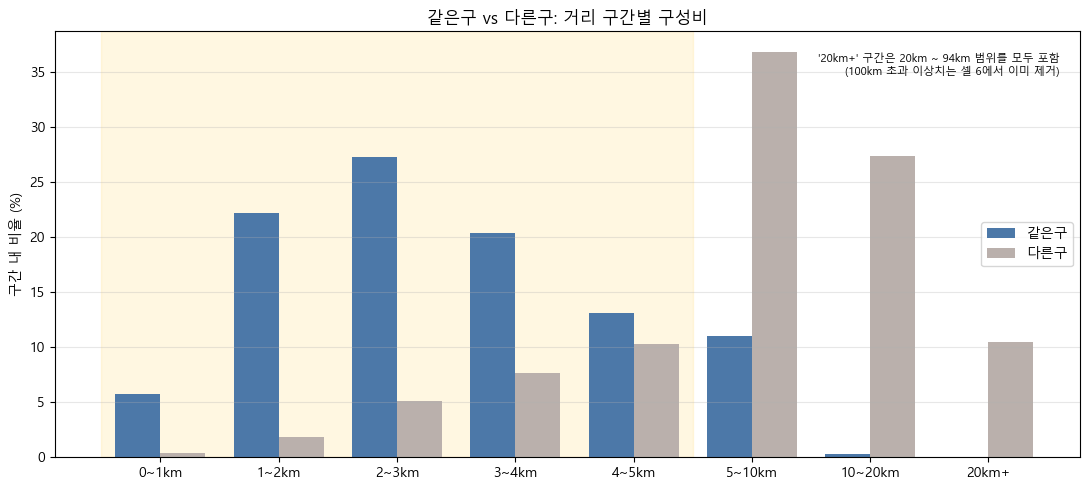

In [13]:
x = np.arange(len(band_labels))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width / 2, band_same.values, width, label="같은구", color="#4c78a8")
ax.bar(x + width / 2, band_diff.values, width, label="다른구", color="#bab0ac")

ax.axvspan(-0.5, 4.5, color="#ffe08a", alpha=0.25, zorder=0)  # 0~5km 구간 강조

ax.set_xticks(x)
ax.set_xticklabels(band_labels)
ax.set_ylabel("구간 내 비율 (%)")
ax.set_title("같은구 vs 다른구: 거리 구간별 구성비")
ax.legend()
ax.grid(axis="y", alpha=0.3)

max_dist_km = pd.concat([same_gu["승차거리"], diff_gu["승차거리"]]).max() / 1000
ax.annotate(
    f"'20km+' 구간은 20km ~ {max_dist_km:.0f}km 범위를 모두 포함\n(100km 초과 이상치는 셀 6에서 이미 제거)",
    xy=(0.98, 0.95), xycoords="axes fraction", ha="right", va="top", fontsize=8,
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig3_04_2_distance_band_same_vs_diff.png", dpi=120, bbox_inches="tight")
plt.show()


## 거리 구간별 비교 관찰 기록 (§4 실행 결과로 확정)

같은구 이동은 **1~5km 구간에 넓게 몰려 있다**(1~2km 22.2%, 2~3km 27.3%[최다 구간], 3~4km 20.4%, 4~5km 13.2% — 이 넷을 합쳐 83.0%). 0~1km 구간(5.8%)만 놓고 보면 오히려 비중이 크지 않다 — "같은구 이동 = 아주 짧은 거리"라기보다 "구 경계 안에서 1~5km 정도를 이동"하는 패턴이 지배적이다.

다른구 이동은 **5km 이상 구간에 넓게 분포**한다(5~10km 36.9%[최다 구간], 10~20km 27.4%, 20km+ 10.5% — 합쳐 74.8%). 이는 §2의 커버리지 차이(같은구 88.7% vs 다른구 25.2%)를 거리 분포 차원에서 뒷받침한다.


In [14]:
coverage_result = coverage_summary.reset_index()
save_path_1 = DATA_DIR / "region_5km_coverage_same_vs_diff_gu_20251231.csv"
coverage_result.to_csv(save_path_1, index=False, encoding="utf-8-sig")
print(f"저장 완료: {save_path_1}")
display(coverage_result)

by_district_to_save = by_district[["자치구", "이동건수", "5km이내건수", "5km이내비율"]]
save_path_2 = DATA_DIR / "region_same_gu_5km_ratio_by_district_20251231.csv"
by_district_to_save.to_csv(save_path_2, index=False, encoding="utf-8-sig")
print(f"저장 완료: {save_path_2}")
display(by_district_to_save.head())

assert len(same_gu) + len(diff_gu) == len(seoul_completed), "같은구+다른구 건수 합이 seoul_completed와 불일치"
assert abs(len(diff_gu) - 836_535) <= 5, f"다른구 이동 건수({len(diff_gu):,})가 04_1 결과(836,535)와 크게 달라 파이프라인 재확인 필요"
print("\n검증 통과 — 같은구+다른구 = 전체 서울 25구 이동, 다른구 건수는 04_1과 일치(오차 5건 이내)")


저장 완료: c:\Users\young\my_project\260901_call_taxi_DA\data\processed\region_5km_coverage_same_vs_diff_gu_20251231.csv


,구분,건수,5km이내비율(%),5km초과비율(%)
0,같은구,526086.0,88.748988,11.251012
1,다른구,836535.0,25.228831,74.771169
2,전체,1362621.0,49.752939,50.247061


저장 완료: c:\Users\young\my_project\260901_call_taxi_DA\data\processed\region_same_gu_5km_ratio_by_district_20251231.csv


,자치구,이동건수,5km이내건수,5km이내비율
0,강북구,12894,12709,0.985652
1,금천구,7486,7369,0.984371
2,성동구,7487,7303,0.975424
3,도봉구,15201,14816,0.974673
4,중랑구,23548,22824,0.969254



검증 통과 — 같은구+다른구 = 전체 서울 25구 이동, 다른구 건수는 04_1과 일치(오차 5건 이내)


## 종합 인사이트

**가설 2-A — 채택**: 같은구 이동을 포함한 전체 5km 이내 비율은 **49.8%**로, 다른구 단독 baseline(25.2%)보다 크게 높다. 04_1의 다소 비관적인 결론("다른구만 보면 절반 이상을 놓친다")과 달리, 같은구 이동(전체의 38.6%)이 대부분(88.7%) 5km 이내이기 때문에 전체 그림은 훨씬 낙관적이다.

**가설 2-B — 채택**: 같은구 이동이라도 자치구별 5km 이내 비율 편차가 크다(67.6%~98.6%, 약 31.0%p 차이). 원인은 검증하지 않았고 관찰 사실만 기록했다.

**04_1 + 04_2 종합 결론**: "5km 이내 우선 안내"는 전체 수요의 절반 가까이(49.8%)를 커버할 수 있지만, 그 절반은 대부분 같은구 내 이동에서 나온다. 다른구 이동(전체 수요의 61.4%)만 놓고 보면 5km 안내가 여전히 절반 이상을 놓친다(04_1 결론: Top30조차 55.7% 미커버). 따라서 서비스 설계는 **"같은구 이동 = 5km 이내 안내로 충분히 커버(88.7%)" / "다른구 이동 = 5km를 완전한 컷오프가 아니라 1차 필터·우선순위로만 활용"**처럼 이동 유형에 따라 다른 안내 전략을 쓰는 것이 데이터에 더 부합한다.

**데이터 품질 발견 (이번 분석에서 새로 확인)**: 계획 문서(§3-1)는 "같은구 이동에는 100km 초과 이상치가 없다"고 사전 확인했으나, 실제 실행 결과 같은구 이동 중 **19건**이 100km를 초과(최댓값 806,728m)하는 것으로 확인됐다 — 출발구=목적구인데 800km대 거리가 기록된 것은 GPS/기록 오류로 추정된다. 100km 초과 이상치 제거(총 92건)는 같은구 19건 + 다른구 73건에 나눠 영향을 준다. 계획 문서의 해당 사전 확인은 이번 실행 결과로 정정이 필요하다(§6 셀 6 참고).

**한계**:
- 자치구별 편차(가설 2-B)의 원인(면적, 형태, 생활권 구조 등)은 검증하지 않았다.
- 04_1과 동일하게 100km 초과 이상치만 제거했고, 그 외 극단치(5~100km 사이 장거리 같은구 이동 등)는 그대로 포함돼 있다.

**후속 과제**: 같은구/다른구를 시간대별·차량구분별(특장차/임차택시)로 나눠 5km 이내 비율이 달라지는지는 이번 범위 밖이며 향후 분석 후보로 남긴다. 100km 초과는 아니지만 같은구 이동치고 비정상적으로 긴 거리(예: 30~100km)가 있는지도 별도 이상치 점검 후보다.
